In [1]:
import matplotlib.pyplot as plt
import gvar as gv
import numpy as np
import pandas as pd
import pathlib
from cycler import cycler

from hadrana.loader import load_c2pt_per_nsquare, load_fits

In [2]:
ensemble = "D251"
ns = 64
correlation_type = "uncorrelated"
bin_size = 2

run_id  = "test-run26"
run_dir = pathlib.Path(f"/home/ck/phd/results/c2pt/D251/D251-c2pt-fits-{run_id}")

# load c2pt data
momentum_shells = [0, 1, 2, 3, 4, 5, 6, 8]
c2pt_per_nsquare = load_c2pt_per_nsquare(ensemble, momentum_shells, bin_size)

In [3]:
def continuum_energy(M, nsquare, ns):
    """
    Continuum dispersion E = sqrt(p^2 + M^2) in LATTICE units.
    M is the dimensionless aM (or a gvar of it); ns is the spatial extent N_s.
    p^2 here is the dimensionless (a p)^2 = (2*pi*n / N_s)^2 * n^2.
    """
    psquared = (2.0 * np.pi / ns) ** 2 * nsquare
    return np.sqrt(psquared + M ** 2)


def psquared_GeV2(nsquare, ainv):
    """
    Lattice momentum squared converted to physical units [GeV^2].
        (a p)^2 = (2*pi*n / N_s)^2 * n^2     (dimensionless)
        p^2     = (a p)^2 * (a^-1)^2          [GeV^2]
    ainv = hbarc / a  is a gvar, so the scale-setting error propagates
    (correlated across all momenta).
    """
    ap2 = (2.0 * np.pi / ns) ** 2 * nsquare   # (a p)^2, lattice units
    return ap2 * ainv ** 2                      # GeV^2

D251 test-run26 binsize02 uncorrelated


,n2,p2[GeV2],Efit(uncorr),Ephys[GeV],d_hess(aE0),d_jkn(aE0),tmin,tmax,chi2dof(corr)
0,0,0.000,0.33817(97),1.0461(68),0.00044,0.00097,17,39,1.17
1,1,0.092,0.3507(11),1.0850(71),0.00051,0.00109,18,40,1.08
2,2,0.184,0.3640(13),1.1259(76),0.00061,0.00126,18,38,0.94
3,3,0.277,0.3772(16),1.1668(83),0.00083,0.00158,18,35,1.13
4,4,0.369,0.3888(22),1.2026(97),0.00064,0.00217,18,32,0.82
5,5,0.461,0.4003(24),1.238(10),0.00239,0.00242,18,32,0.75
6,6,0.553,0.4127(30),1.277(12),0.00185,0.00303,18,30,0.98
7,8,0.738,0.4282(46),1.324(16),0.00312,0.00462,17,26,1.75


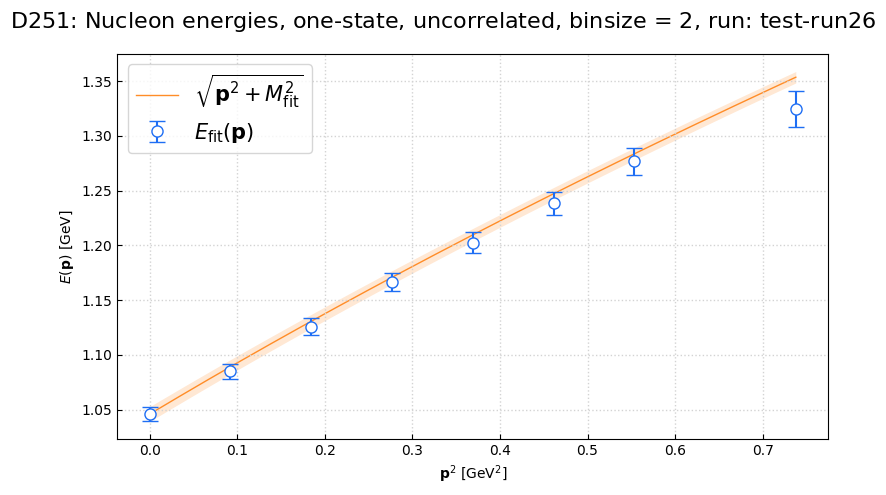

In [4]:
hbarc = 0.1973269804                 # GeV·fm
a_fm  = gv.gvar("0.06379(37)")       # scale-setting value + error (correlated across all p)
ainv  = hbarc / a_fm                 # GeV

for run_id in ["test-run26"]:
    run_dir = pathlib.Path(f"/home/ck/phd/results/c2pt/D251/D251-c2pt-fits-{run_id}")

    # --- rest mass from n2 = 0 ---
    p0_fits = load_fits(run_dir, ensemble, 0, "one-state-exp", correlation_type, bin_size)
    if not p0_fits:
        raise FileNotFoundError(f"No n2=0 one-state fit in {run_dir} (corr={correlation_type!r})")
    M_fit = gv.gvar(p0_fits[0]["E0"], p0_fits[0]["E0_err"])
    M_GeV = M_fit * ainv

    # --- build E(p) and p^2 over all shells, same order ---
    E_GeV_list, p2_GeV_list = [M_GeV], [psquared_GeV2(0, ainv)]
    for nsq in momentum_shells[1:]:
        fits = load_fits(run_dir, ensemble, nsq, "one-state-exp", correlation_type, bin_size)
        if not fits:
            raise FileNotFoundError(f"No n2={nsq} one-state fit in {run_dir}")
        E_fit = gv.gvar(fits[0]["E0"], fits[0]["E0_err"])
        E_GeV_list.append(E_fit * ainv)
        p2_GeV_list.append(psquared_GeV2(nsq, ainv))

    E_GeV = np.array(E_GeV_list)
    p2    = gv.mean(p2_GeV_list)          # p^2 means for plotting/x-axis

    # --- table ---
    rows = []
    for nsq, p2_val, E in zip(momentum_shells, p2, E_GeV):
        fit        = load_fits(run_dir, ensemble, nsq, "one-state-exp", correlation_type, bin_size)[0]
        fit_corr   = load_fits(run_dir, ensemble, nsq, "one-state-exp", "correlated", bin_size)[0]
        rows.append({
            "n2":            nsq,
            "p2[GeV2]":      f"{p2_val:.3f}",
            "Efit(uncorr)":  gv.gvar(fit["E0"], fit["E0_err"]),     # aE0 ± jackknife
            "Ephys[GeV]":    E,
            "d_hess(aE0)":   f'{fit["E0_err_hess"]:.5f}',
            "d_jkn(aE0)":    f'{fit["E0_err_jkn"]:.5f}',
            "tmin":          fit["tmin"],
            "tmax":          fit["tmax"],
            "chi2dof(corr)": f'{fit_corr["chi2dof"]:.2f}',
        })
    df = pd.DataFrame(rows)
    print(f"{ensemble} {run_id} binsize{bin_size:02d} {correlation_type}")
    display(df)

    # --- plot ---
    blue, orange = "#1E6EF4", "#ff8d28"
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(p2, gv.mean(E_GeV), yerr=gv.sdev(E_GeV),
                fmt="o", mfc="white", color=blue, ms=8, capsize=6, zorder=2,
                label=r"$E_{\mathrm{fit}}(\mathbf{p})$")

    grid   = np.linspace(0, p2.max(), 200)
    Ecurve = gv.sqrt(grid + M_GeV**2)     # curve pinned through n2=0 by construction
    ax.plot(grid, gv.mean(Ecurve), color=orange, lw=1, zorder=1,
            label=r"$\sqrt{\mathbf{p}^2 + M_{\mathrm{fit}}^2}$")
    ax.fill_between(grid, gv.mean(Ecurve) - gv.sdev(Ecurve),
                    gv.mean(Ecurve) + gv.sdev(Ecurve),
                    color=orange, alpha=0.2, lw=0)

    ax.set_xlabel(r"$\mathbf{p}^2\ [\mathrm{GeV}^2]$")
    ax.set_ylabel(r"$E(\mathbf{p})\ [\mathrm{GeV}]$")
    ax.legend(fontsize=15, loc="upper left")
    ax.grid(color="lightgrey", linestyle=":", linewidth=1)
    ax.tick_params(direction="in")
    fig.suptitle(rf"$\mathsf{{{ensemble}}}$: Nucleon energies, one-state, {correlation_type}, "
                 rf"binsize = {bin_size}, run: {run_id}", fontsize=16)
    fig.tight_layout()
    plt.show()